In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("/Users/senarajayawardena/Documents/Dialog/20260512_FintechTrainee_CaseStudy_Dataset_FinSightLanka_F.xlsx")


Data Cleaning

In [3]:
# Remove duplicates
dup_mask = df["Customer_ID"].duplicated() | df["NIC_Number"].duplicated()
df = df[dup_mask].reset_index(drop=True)
print(f"Removed {dup_mask.sum()} duplicates → {len(df):,} rows remain")

Removed 11 duplicates → 11 rows remain


In [6]:
# Gender
df["Gender"] = df["Gender"].str.strip().str.capitalize().replace({"M": "Male", "F": "Female"})

# Account Status
df["Account_Status"] = df["Account_Status"].str.strip().str.capitalize()

# District typos
df["District"] = df["District"].replace({"Columbo": "Colombo", "Kanady": "Kandy", "Gale": "Galle", "Jafna": "Jaffna"})

# Province from District
DISTRICT_TO_PROVINCE = {
    "Colombo": "Western", "Gampaha": "Western", "Kandy": "Central",
    "Badulla": "Uva", "Trincomalee": "Eastern", "Jaffna": "Northern",
    "Galle": "Southern", "Matara": "Southern", "Kurunegala": "North Western",
    "Ratnapura": "Sabaragamuwa",
}
df["Province"] = df["District"].map(DISTRICT_TO_PROVINCE).combine_first(df["Province"])

In [ ]:
# counts missing values per column and shows only columns that have at least one missing value,
# sorted by most missing first.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"Count": missing, "%": missing_pct})
      .query("Count > 0")
      .sort_values("Count", ascending=False))

                          Count     %
FD_Amount                   358  70.5
Loan_Amount                 291  57.3
Loan_Tenure_Months          290  57.1
Monthly_Repayment_Amount    290  57.1
Loan_Type                   290  57.1
Outstanding_Loan_Balance    289  56.9
Loan_Start_Date             288  56.7
Loan_Repayment_Status       288  56.7
Referral_Source             252  49.6
Last_Login_Date             169  33.3
Full_Name                     8   1.6
KYC_Status                    7   1.4
Monthly_Deposit_Avg           6   1.2
Savings_Balance               6   1.2
District                      5   1.0
Has_Loan                      5   1.0
Customer_Segment              5   1.0


In [8]:
# Null out bad values
df.loc[df["Savings_Balance"] < 0, "Savings_Balance"] = np.nan
df.loc[df["Savings_Balance"] >= 999_000_000, "Savings_Balance"] = np.nan

# Impute with segment median
df["Savings_Balance"] = df.groupby("Customer_Segment")["Savings_Balance"] \
                          .transform(lambda x: x.fillna(x.median()))

In [9]:
# nulls out negative deposits (impossible), 
# fills missing deposits and withdrawals with their median, 
# then recalculates net flow.

# Fix deposits
df.loc[df["Monthly_Deposit_Avg"] < 0, "Monthly_Deposit_Avg"] = np.nan
df["Monthly_Deposit_Avg"] = df["Monthly_Deposit_Avg"].fillna(df["Monthly_Deposit_Avg"].median())

# Fix withdrawals
df["Monthly_Withdrawal_Avg"] = df["Monthly_Withdrawal_Avg"].fillna(df["Monthly_Withdrawal_Avg"].median())

# Recompute net flow
df["Net_Monthly_Flow"] = df["Monthly_Deposit_Avg"] - df["Monthly_Withdrawal_Avg"]

In [11]:
#fills missing Has_Loan based on whether Loan_Amount exists, 
#then checks that non-borrowers don't have any loan data filled in.


# Infer Has_Loan from Loan_Amount
mask = df["Has_Loan"].isna()
df.loc[mask & df["Loan_Amount"].notna(), "Has_Loan"] = "Yes"
df.loc[mask & df["Loan_Amount"].isna(),  "Has_Loan"] = "No"

# Check for spurious loan data on non-borrowers
loan_cols = ["Loan_Amount", "Loan_Tenure_Months", "Monthly_Repayment_Amount",
             "Outstanding_Loan_Balance", "Loan_Type", "Loan_Repayment_Status"]

spurious = df.loc[df["Has_Loan"] == "No", loan_cols].notna().sum()
print(spurious[spurious > 0])  # prints only problem columns

Loan_Amount                 1
Loan_Tenure_Months          1
Monthly_Repayment_Amount    1
Outstanding_Loan_Balance    2
Loan_Type                   1
Loan_Repayment_Status       3
dtype: int64


In [12]:
for col in ["Customer_Segment", "District", "KYC_Status"]:
    df[col] = df[col].fillna("Unknown")

In [14]:
#recalculates tenure from Account_Open_Date and overwrites the existing column
#(ignoring whatever was there before).

REF_DATE = pd.Timestamp("2026-05-01")
df["Customer_Tenure_Years"] = ((REF_DATE - df["Account_Open_Date"]).dt.days / 365.25).round(1)



In [15]:
#creates 5 new columns 
#age groups, debt-to-savings ratio, savings growth flag, cross-sell candidates, and high-risk flag.


# Age bands
df["Age_Band"] = pd.cut(df["Age"], bins=[17,24,34,44,54,64,100],
                        labels=["18-24","25-34","35-44","45-54","55-64","65+"])

# Debt-to-Savings (loan holders with positive savings only)
mask = (df["Has_Loan"] == "Yes") & df["Outstanding_Loan_Balance"].notna() & (df["Savings_Balance"] > 0)
df["Debt_to_Savings"] = np.where(mask, df["Outstanding_Loan_Balance"] / df["Savings_Balance"], np.nan)

# Savings growing
df["Savings_Growing"] = df["Net_Monthly_Flow"] > 0

# Cross-sell opportunity
df["CrossSell_Opportunity"] = (df["Savings_Balance"] > 0) & (df["Has_Fixed_Deposit"] == "No") & (df["Has_Insurance"] == "No")

# High risk
df["High_Risk_Flag"] = (df["Debt_to_Savings"] > 1.0) & (df["Loan_Repayment_Status"] == "Defaulted")


Age_BandGroups customers by age — e.g. 18-24, 25-34, etc. Useful for segment 
analysis

Debt_to_SavingsHow much loan debt a customer has relative to their savings. > 1.0 
means they owe more than they have saved — financially stressed

Savings_GrowingTrue if deposits > withdrawals that month — customer is saving more than spending

CrossSell_OpportunityTrue if customer has savings but no fixed deposit and no insurance — good candidate to sell those products to

High_Risk_FlagTrue if customer has more debt than savings AND has already defaulted — highest priority risk customers

In [17]:
#final sanity check — prints the cleaned dataframe's shape, how many rows were dropped, any remaining nulls, and column data types.

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Rows removed: {510 - len(df)}")  # replace 510 with your actual raw row count
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df.dtypes)

Shape: 508 rows × 49 columns
Rows removed: 2
Full_Name                     8
Savings_Balance               5
Loan_Type                   290
Loan_Amount                 291
Loan_Tenure_Months          290
Monthly_Repayment_Amount    290
Loan_Repayment_Status       288
Loan_Start_Date             288
Outstanding_Loan_Balance    289
Last_Login_Date             169
FD_Amount                   358
Referral_Source             252
Age_Band                      3
Debt_to_Savings             293
dtype: int64
Customer_ID                          object
Full_Name                            object
NIC_Number                           object
Gender                               object
Date_of_Birth                datetime64[ns]
Age                                   int64
District                             object
Province                             object
Urban_Rural                          object
Customer_Segment                     object
Account_Open_Date            datetime64[ns]
Customer_T

In [18]:
df.to_csv("finsight_clean.csv", index=False)

EDA


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import os, warnings
warnings.filterwarnings("ignore")

os.makedirs("eda_output", exist_ok=True)

NAVY, BLUE, GREEN, AMBER, RED, GREY, LGREY = "#1B4F72","#2E86C1","#1E8449","#D4861A","#C0392B","#7F8C8D","#ECF0F1"
PALETTE_SEG  = {"Premium": NAVY, "Regular": BLUE, "Starter": AMBER, "Unknown": GREY}
PALETTE_CHAN  = {"Agent": NAVY, "Branch": BLUE, "Digital": GREEN, "Referral": AMBER}

fmt_lkr = lambda x, p=None: f"LKR {x/1e6:.1f}M" if x>=1e6 else f"LKR {x/1e3:.0f}K" if x>=1e3 else f"LKR {x:.0f}"
pct     = lambda n, d: 0 if d == 0 else round(100 * n / d, 1)

In [20]:
# Quick stats
print(f"Customers: {len(df):,} | Provinces: {df['Province'].nunique()} | Districts: {df['District'].nunique()}")
print(f"Avg tenure: {df['Customer_Tenure_Years'].mean():.1f} yrs | Total savings: LKR {df['Savings_Balance'].sum()/1e6:.1f}M")

# Value counts for key columns
for col in ["Customer_Segment", "Province", "Acquisition_Channel", "Account_Status", "KYC_Status"]:
    print(f"\n{col}:\n{df[col].value_counts().to_string()}")

Customers: 508 | Provinces: 8 | Districts: 11
Avg tenure: 6.8 yrs | Total savings: LKR 385.0M

Customer_Segment:
Customer_Segment
Regular    319
Starter     93
Premium     91
Unknown      5

Province:
Province
Western          105
Southern          82
Northern          59
Sabaragamuwa      58
North Western     56
Eastern           51
Uva               50
Central           47

Acquisition_Channel:
Acquisition_Channel
Referral    132
Digital     132
Branch      126
Agent       118

Account_Status:
Account_Status
Active       384
Inactive      81
Suspended     43

KYC_Status:
KYC_Status
Verified    358
Expired      73
Pending      70
Unknown       7


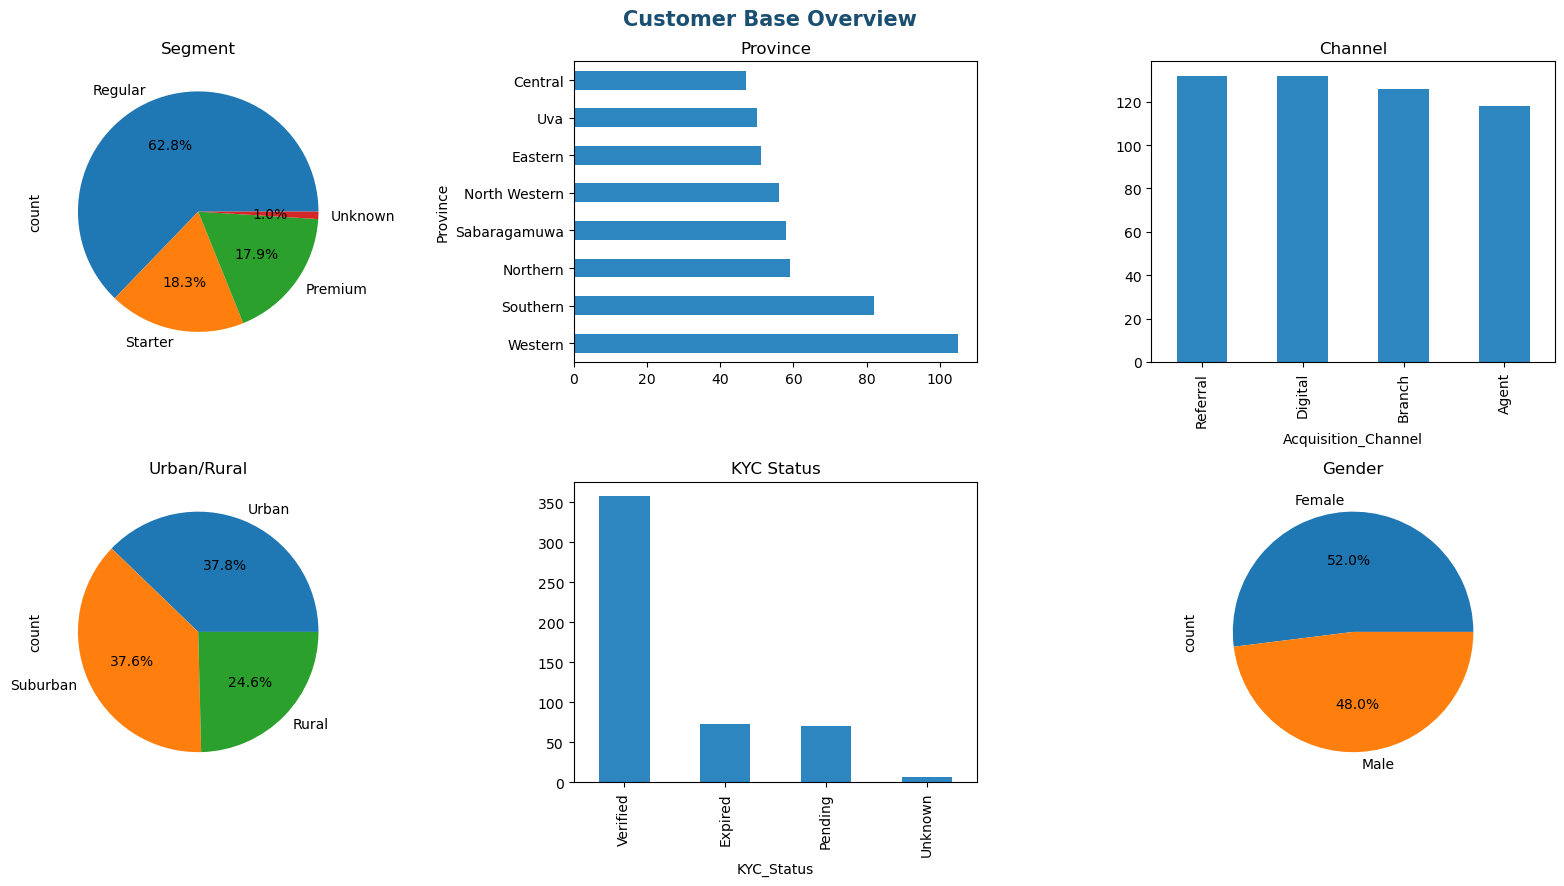

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Customer Base Overview", fontsize=15, fontweight="bold", color=NAVY)

df["Customer_Segment"].value_counts().plot.pie(ax=axes[0,0], autopct="%1.1f%%", title="Segment")
df["Province"].value_counts().plot.barh(ax=axes[0,1], title="Province", color=BLUE)
df["Acquisition_Channel"].value_counts().plot.bar(ax=axes[0,2], title="Channel", color=BLUE)
df["Urban_Rural"].value_counts().plot.pie(ax=axes[1,0], autopct="%1.1f%%", title="Urban/Rural")
df["KYC_Status"].value_counts().plot.bar(ax=axes[1,1], title="KYC Status", color=BLUE)
df["Gender"].value_counts().plot.pie(ax=axes[1,2], autopct="%1.1f%%", title="Gender")

plt.tight_layout()
plt.show()

         Age  Savings_Balance  Monthly_Deposit_Avg  Monthly_Withdrawal_Avg  \
count  508.0            503.0                508.0                   508.0   
mean    37.0         765456.2              37633.4                 59007.5   
std     12.1        1080667.3              57631.6                592686.2   
min      4.0           5945.0                194.8                   101.0   
25%     28.0         122290.3               5759.0                  3230.3   
50%     36.5         448866.7              17694.7                  9684.8   
75%     45.0         728410.7              39352.6                 22889.2   
max    150.0        4916005.1             347140.1               9999999.0   

       Net_Monthly_Flow  Customer_Tenure_Years  Monthly_Transaction_Count  
count             508.0                  508.0                      508.0  
mean           -21374.1                    6.8                       12.8  
std            594092.3                    2.7                       

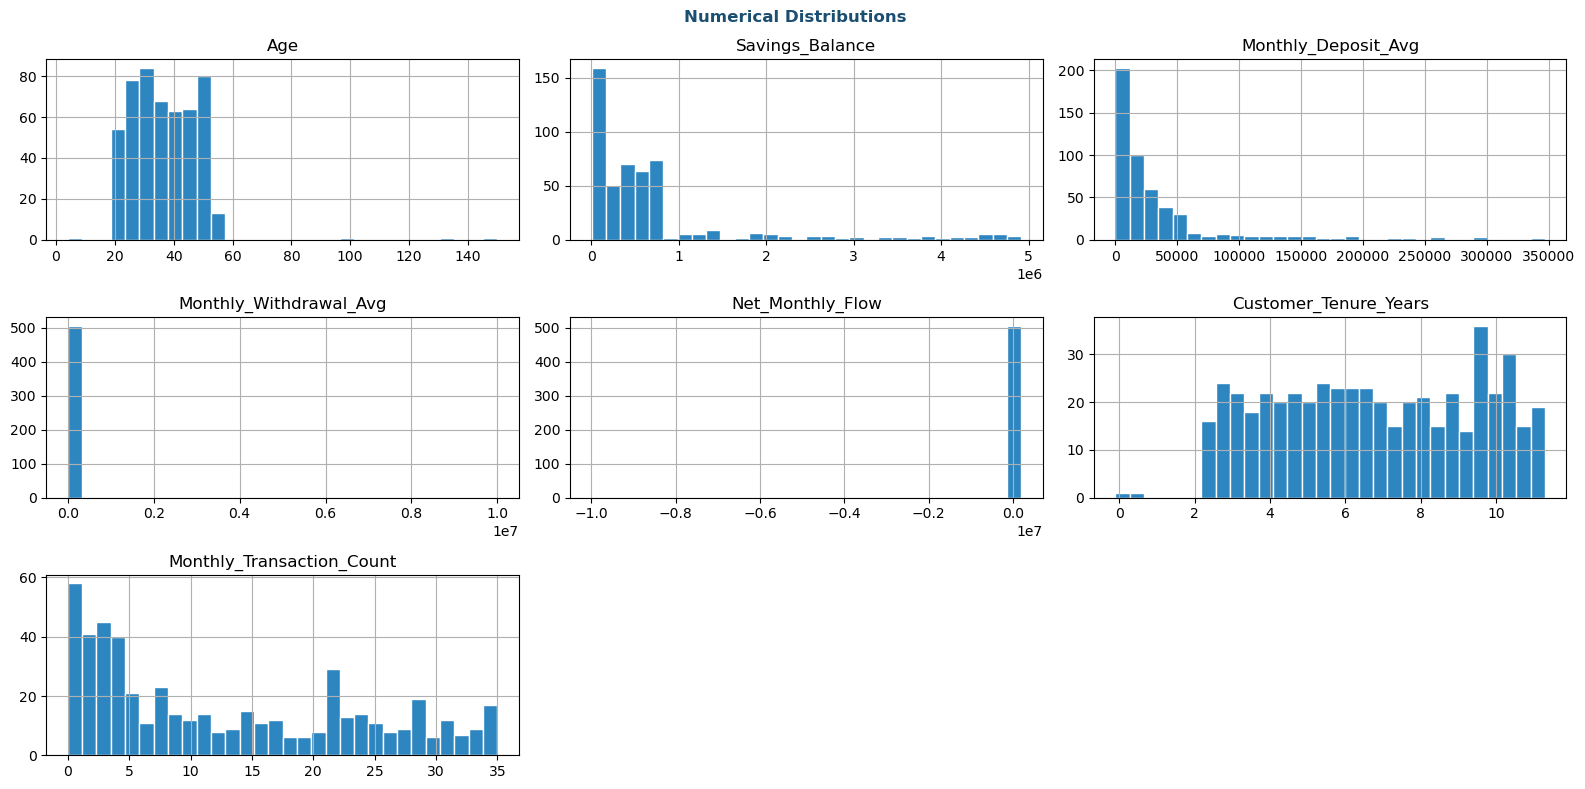

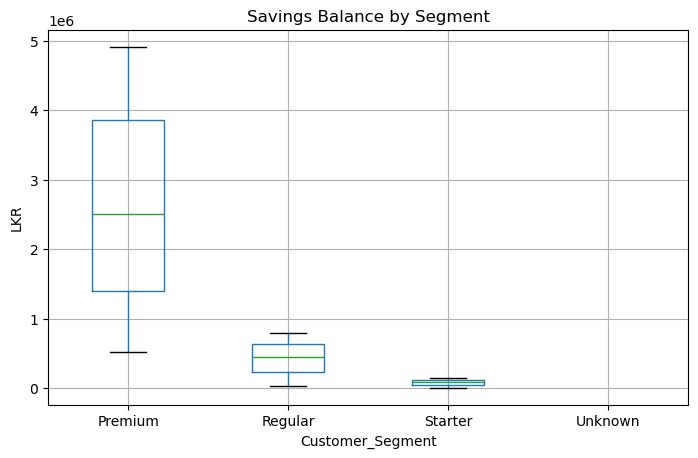

In [22]:
num_cols = ["Age", "Savings_Balance", "Monthly_Deposit_Avg", "Monthly_Withdrawal_Avg",
            "Net_Monthly_Flow", "Customer_Tenure_Years", "Monthly_Transaction_Count"]

# Stats
print(df[num_cols].describe().round(1))

# Distributions
df[num_cols].hist(bins=30, figsize=(16, 8), color=BLUE, edgecolor="white")
plt.suptitle("Numerical Distributions", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

# Savings by segment
df.boxplot(column="Savings_Balance", by="Customer_Segment", figsize=(8, 5))
plt.suptitle("")
plt.title("Savings Balance by Segment")
plt.ylabel("LKR")
plt.show()